# nVidia stock returns EDA

In this project we,

- use Yahoo Finance and Quantmod APIs to download nVidia stock data
- investigate and clean the dataset
- visualise the shape of the data

Core packages

- https://cran.r-project.org/web/packages/yahoofinancer/index.html
- https://cran.r-project.org/web/packages/quantmod/index.html

In our analysis, we draw on [Forecasting: Principles and Practice](https://otexts.com/fpp3/) and other material on time series.

In [ ]:
# Libraries
library(tidyverse)
library(tsibble)
#library(fable)
#library(feasts)
#library(ggtime)
library(zoo)
library(rvest)
library(httr2)
library(yahoofinancer)
library(quantmod)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'tsibble'


The following object is masked from 'package:lubridate':

    interval


The following objects are masked from 'package:base':

    intersect, setdiff, union



Attaching package: 'rvest'


The following object is masked from 'package:readr':

    guess_encoding


Loading required package: xts

Loading required package: zoo


Attaching package: 'zoo'


The following object is masked from 'package:tsibble':

    index


The following objects

## Workings

### Helpers

In [143]:
# Aggregate a df of time series
aggregate_ts <- function(df, unit = "month", agg = "mean") {

    if (is.null(df$date) || !is.Date(df$date)) {
        warning("date column either missing or not properly formatted.")
        return(NULL)
    }

    fn_list <- list(
        mean = ~ mean(.x, na.rm = TRUE),
        min = ~ min(.x, na.rm = TRUE),
        median = ~ median(.x, na.rm = TRUE),
        max = ~ max(.x, na.rm = TRUE)
    )

    as_tibble(df) |>
        mutate(period = floor_date(date, unit)) |>
        group_by(period) |>
        summarise(
            across(
                .cols = where(is.numeric), 
                .fns = fn_list[names(fn_list) %in% agg], 
                .names = "{.col}_{.fn}"
            ), .groups = "drop"
        ) |>
        rename(date = period)
}

# Bin width for fat tails
freedman_diaconis <- function(vec) {
    bin_width <- 2 * IQR(vec) * length(vec)^(-1 / 3)
    return(bin_width)
}

# Lag a column
lag_col <- function(df, col, k = 9) {
    df <- df |>
        rename(!!paste0(col, "_l00") := !!sym(col))

    for (i in seq(k)) {
        current_lag <- paste0(col, "_l", str_pad(i, width = 2, pad = "0"))
        previous_lag <- paste0(col, "_l", str_pad(i - 1, width = 2, pad = "0"))

        df <- df |>
            mutate(
                !!current_lag := lag(!!sym(previous_lag))
            )
    }

    df |>
        drop_na()
}

# Compute log returns
log_returns <- function(df) {
    if (is.null(df$date) || !is.Date(df$date)) {
        warning("date column either missing or not properly formatted.")
        return(NULL)
    }

    df |>
        mutate(
            across(
                .cols = where(is.numeric),
                .fns = ~ log(.x) - log(lag(.x)),
                .names = "{.col}_lr"
            )
        ) |>
        select(date, ends_with("_lr")) |>
        slice(2:n())
}

# Bin width
scott <- function(vec) {
    bin_width <- 3.5 * sd(vec) * length(vec)^(-1 / 3)
}

In [3]:
# Set up Jupyter graph display
options(
  repr.plot.width  = 10,
  repr.plot.height = 6,
  repr.plot.res    = 150
)

### Clean and investigate the dataset

In [37]:
# nVidia stock
nvidia <-  Ticker$new("NVDA")

cat("\nnVidia stock ticker readout:\n")
nvidia


nVidia stock ticker readout:


<Ticker>
  Public:
    clone: function (deep = FALSE) 
    currency: active binding
    exchange_name: active binding
    exchange_timezone_name: active binding
    fifty_two_week_high: active binding
    fifty_two_week_low: active binding
    first_trade_date: active binding
    full_exchange_name: active binding
    get_history: function (period = "ytd", interval = "1d", start = NULL, end = NULL) 
    initialize: function (symbol = NA) 
    previous_close: active binding
    recommendations: active binding
    regular_market_day_high: active binding
    regular_market_day_low: active binding
    regular_market_price: active binding
    regular_market_time: active binding
    regular_market_volume: active binding
    set_symbol: function (symbol) 
    symbol: NVDA
    technical_insights: active binding
    timezone: active binding
    valuation_measures: active binding
  Private:
    base_url: https://query2.finance.yahoo.com
    cors_domain: finance.yahoo.com
    extract_valuation: f

In [38]:
# Extract dividends and splits from Yahoo Finance
dividends <- quantmod::getDividends("NVDA", from = "1970-01-01", auto.assign = FALSE)
splits <- quantmod::getSplits("NVDA",    from = "1970-01-01", auto.assign = FALSE)

# Construct data frames
div_df <- tibble(date = zoo::index(dividends), dividend = as.numeric(dividends)) |>
    mutate(date = ymd(date))

spl_df <- tibble(date = zoo::index(splits), split = as.numeric(splits)) |>
    mutate(date = ymd(date))

In [39]:
# Extract the history
nvidia_df <- nvidia$get_history(start = ymd("1970-01-01"), interval="1d")

In [40]:
# Join the series in a single data frame
nvidia_df <- nvidia_df |>
    janitor::clean_names() |>
    select(-adj_close) |>
    as_tibble() |>
    #mutate(date = as.Date(date)) |>
    mutate(date = as_date(date)) |>
    left_join(div_df, by = "date") |>
    left_join(spl_df, by = "date")

In [41]:
# Select duplicates
dupe <- nvidia_df |>
    duplicates(index = date)

# Keep only the latest entry
nvidia_df <- nvidia_df |>
    filter(!(date == tail(dupe$date, n = 1)) & !(volume == tail(dupe$volume, n = 1)))

In [42]:
# Convert the df into a tsibble
nvidia_tsdf <- nvidia_df |>
    as_tsibble(
        index = date,
        key = colnames(nvidia_df |> select(-date))
    )

In [ ]:
# Sample splits
nvidia_df |> 
    filter(!is.na(split)) |>
    sample_n(5)

date,volume,high,low,open,close,dividend,split
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2024-06-10,313434100,123.099998,117.010002,120.370003,121.790001,NA,0.1000000
2006-04-07,682674000,0.512500,0.498833,0.508000,0.508833,NA,0.5000000
2007-09-11,405424000,0.871000,0.847750,0.856750,0.864500,NA,0.6666667
2000-06-27,604608000,0.348438,0.287760,0.342708,0.296875,NA,0.5000000
2021-07-20,434687000,18.837999,18.164000,18.730000,18.612000,NA,0.2500000


In [ ]:
# Sample dividends
nvidia_df |> 
    filter(!is.na(dividend)) |>
    sample_n(5)

date,volume,high,low,open,close,dividend,split
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2018-11-29,549172000,4.03750,3.90350,4.00000,3.93400,0.004000,NA
2018-02-22,534364000,6.14075,5.98750,6.06825,6.05375,0.003750,NA
2017-11-22,356640000,5.42500,5.34025,5.42500,5.37325,0.003750,NA
2016-08-23,339764000,1.58300,1.56825,1.57600,1.57275,0.002875,NA
2015-11-18,350216000,0.77675,0.75200,0.76025,0.77575,0.002875,NA


The dataset is missing Saturdays and Sundays since stock exchanges shut for weekends. For the sake of simplicity, we shall ignore the Monday effect.

#### Missing values and duplicates

In [66]:
# Check NAs
cat("\nNAs per column:\n")
nvidia_df |>
    summarise(
        across(
            .cols = everything(),
            .fns = ~ sum(is.na(.))
        )
    )


NAs per column:


date,volume,high,low,open,close,dividend,split
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,0,6773,6822


In [65]:
# Check number of dividends and splits
cat("\nNumber of dividends and splits:\n")
nvidia_df |>
    select(dividend, split) |>
    summarise(
        across(
            .cols = everything(),
            .fns = ~ sum(!is.na(.))
        )
    )


Number of dividends and splits:


dividend,split
<int>,<int>
54,5


In [47]:
# Inspect the missing values
#nvidia_df |>
#    filter(!is.na(dividend) | !is.na(split))

In [64]:
# Check noughts
cat("\nNumber of zeros per numeric column:\n")
nvidia_df |> select(where(is.numeric)) |> summarise(across(everything(), ~ sum(.x == 0)))


Number of zeros per numeric column:


volume,high,low,open,close,dividend,split
<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,NA,NA


In [58]:
# Check negatives
cat("\nNumber of negative values per numeric column:\n")
nvidia_df |> select(where(is.numeric)) |> summarise(across(everything(), ~ sum(.x < 0)))


Number of negative values per numeric column:


volume,high,low,open,close,dividend,split
<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,NA,NA


In [63]:
# Check duplicate rows
cat("\nNumber of duplicate rows in df:")
nvidia_df |> duplicated() |> sum()


Number of duplicate rows in df:

[1] 0

In [62]:
# Check duplicated dates
cat("\nNumber of duplicate dates:")
nvidia_df |> select(date) |> duplicated() |> sum()


Number of duplicate dates:

[1] 0

In [61]:
# Check the date
init_date <- min(nvidia_df$date) #|> as_datetime(origin = lubridate::origin, tz = "UTC")
conc_date <- max(nvidia_df$date) #|> as_datetime(origin = lubridate::origin, tz = "UTC")
cat("\nThe first and the last date of the series:\n", format(init_date, "%Y-%m-%d"), "\n", format(conc_date, "%Y-%m-%d"))


The first and the last date of the series:
 1999-01-22 
 2026-03-13

### Basic EDA

#### Process

In [67]:
monthly_ts <- aggregate_ts(nvidia_df)

cat("\nDataset sample:\n")
monthly_ts |> sample_n(5)


Dataset sample:


date,volume_mean,high_mean,low_mean,open_mean,close_mean,dividend_mean,split_mean
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2004-02-01,624358105,0.19512279,0.18876310,0.19190353,0.1916887,NaN,NaN
1999-07-01,179241143,0.04332833,0.04128857,0.04249748,0.0423580,NaN,NaN
2001-12-01,882432000,0.54101659,0.51840015,0.52615830,0.5317167,NaN,NaN
2018-02-01,785027789,6.05817110,5.79536845,5.94115797,5.9176711,0.003750,NaN
2013-02-01,521141053,0.31500000,0.30710527,0.31013158,0.3110789,0.001875,NaN



Raw series plot:


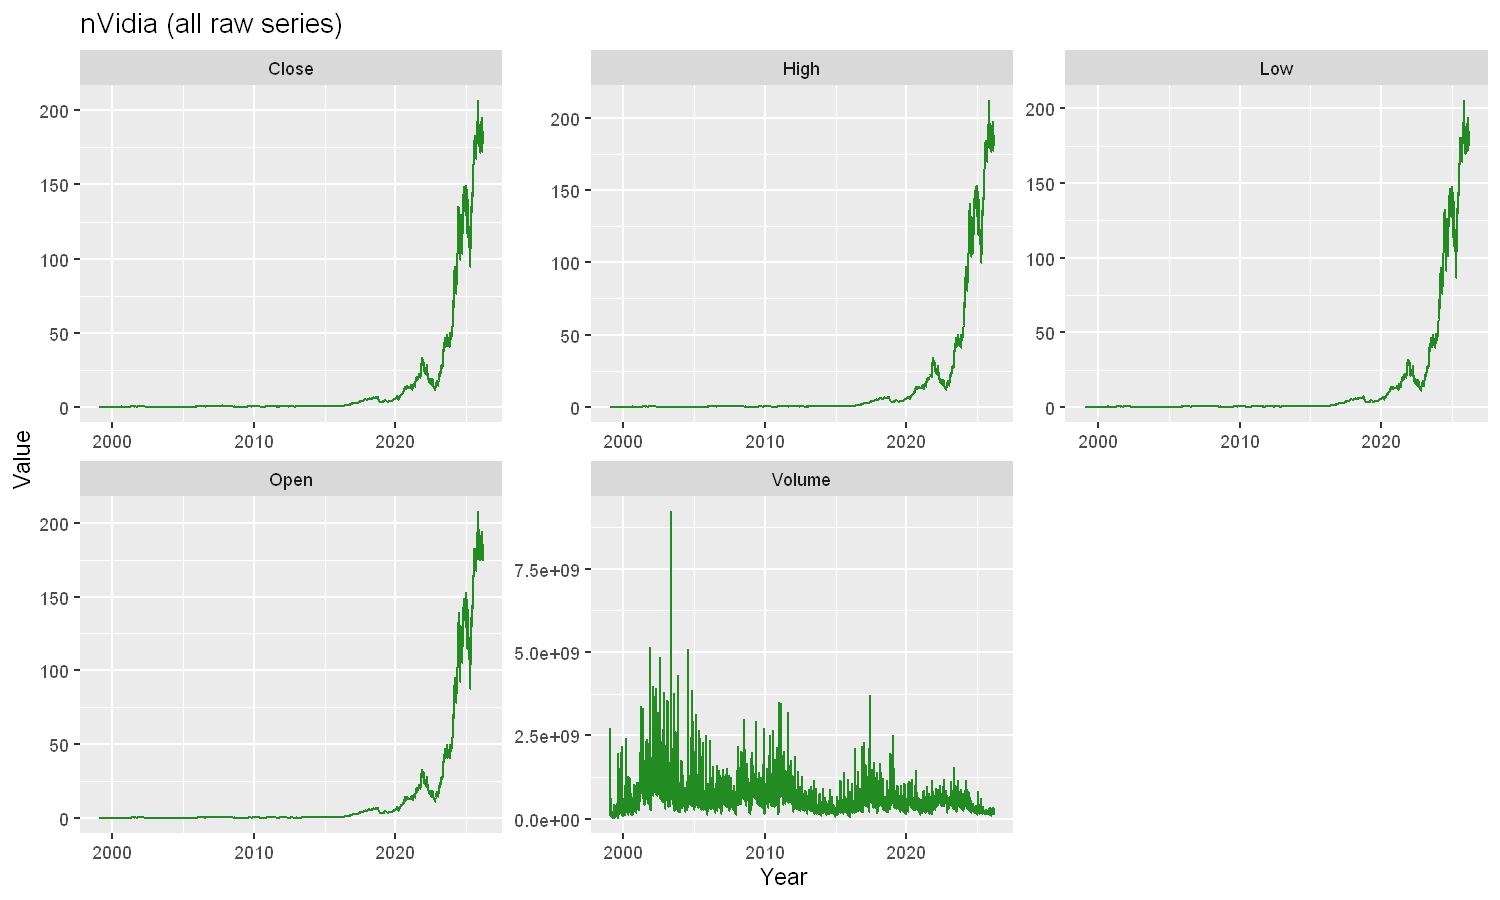

In [137]:
# The shape of the series
# Emulate tsibble() |> autoplot()
cat("\nRaw series plot:\n")
nvidia_df |>
    pivot_longer(
        cols = -c("date", "dividend", "split"),
        names_to = "var",
        values_to = "val"
    ) |>
    mutate(var = str_to_sentence(var)) |>
    ggplot(aes(x = date, y = val)) +
    geom_line(colour = "forestgreen") +
    facet_wrap(~var, scales = "free", ncol = 3) + 
    labs(title = "nVidia (all raw series)", x = "Year", y = "Value")


We can see that, although the volume traded decreases over time, the price begins to grow exponentially as of 2020.

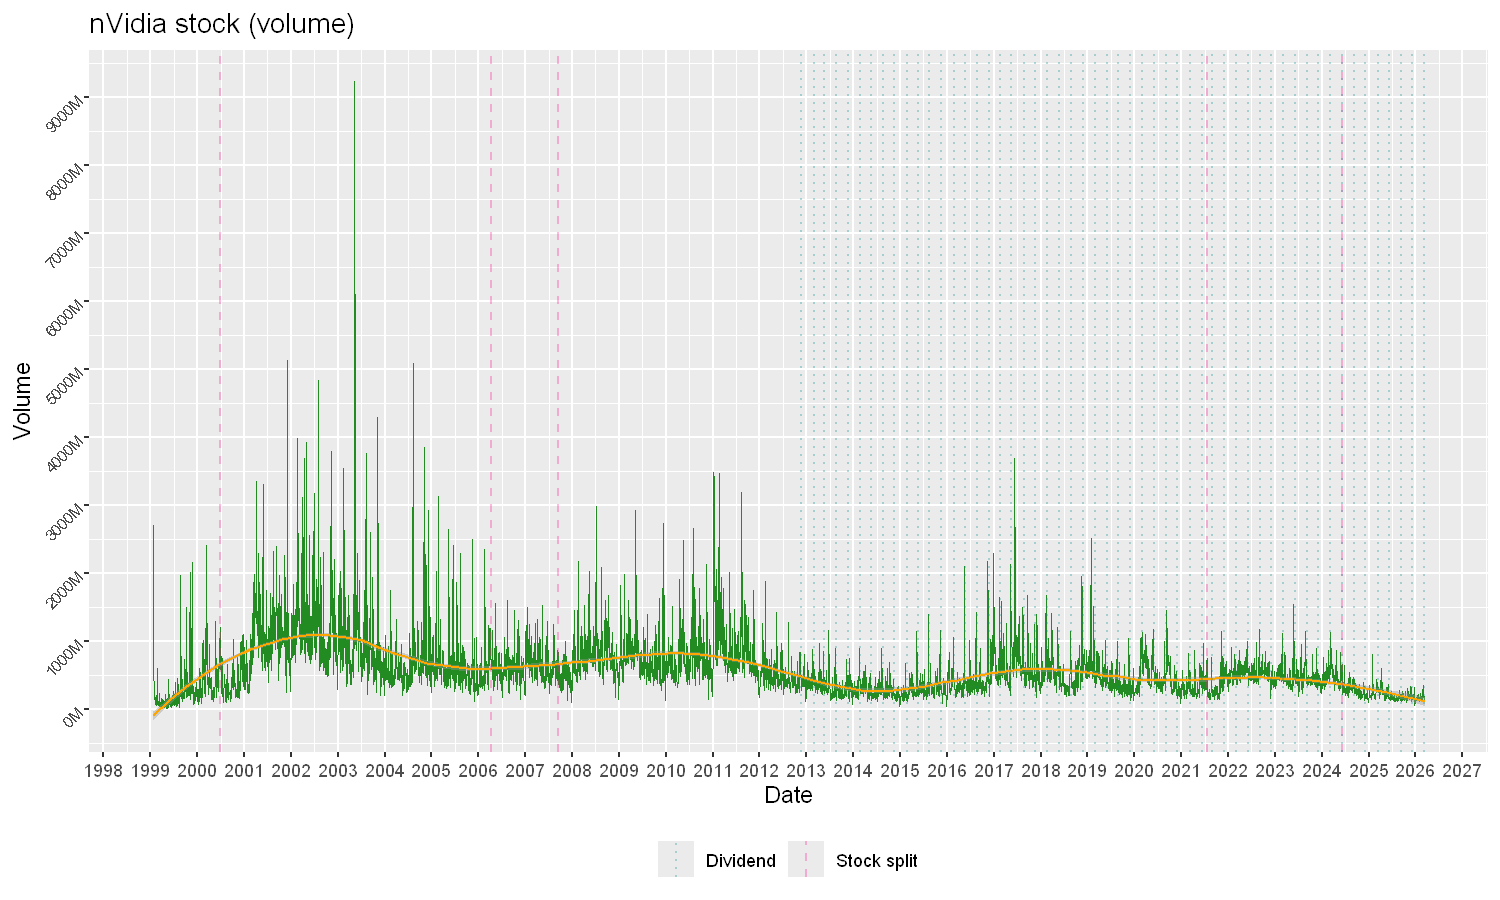

In [261]:
# Volume
spl <- nvidia_df |> filter(!is.na(split)) |> select(date)
div <- nvidia_df |> filter(!is.na(dividend)) |> select(date)
vscale_vec <- nvidia_df$volume

nvidia_df |>
    select(date, volume) |>
    ggplot(aes(x = date, y = volume)) + 
    geom_line(linewidth = 0.4, colour = "forestgreen") +
    geom_smooth(
        method = "loess",
        span = 0.3, 
        level = 0.99,
        formula = y ~ x,
        se = TRUE, # CI
        colour = "orange",
        linewidth = 0.6,
        alpha = 0.4
    ) +
    geom_vline(
        data = spl,
        aes(xintercept = date, colour = "Stock split"),
        linetype = "dashed",
        linewidth = 0.6,
        alpha = 0.3
    ) +
    geom_vline(
        data = div,
        aes(xintercept = date, colour = "Dividend"),
        linetype = "dotted",
        linewidth = 0.6,
        alpha = 0.3
    ) +
    scale_y_continuous(
        labels = \(x) paste0(x / 1e6, "M"),
        #limits = c(
        #    min(vscale_vec, na.rm = TRUE) - abs(min(vscale_vec, na.rm = TRUE) * 0.1), 
        #    max(vscale_vec, na.rm = TRUE) + abs(max(vscale_vec, na.rm = TRUE) * 0.1)
        #    ),
        breaks = scales::pretty_breaks(n = 10)
    ) +
    scale_x_date(
        date_breaks = "1 year",
        date_labels = "%Y"
    ) +
    scale_colour_manual(
        name   = NULL,
        values = c("Stock split" = "deeppink", "Dividend" = "darkcyan")
    ) +
    labs(
        title = "nVidia stock (volume)",
        x = "Date",
        y = "Volume"
    ) +
    #theme_minimal() +
    theme(
        legend.position = "bottom",
        axis.text.y = element_text(angle = 45, hjust = 1, size = 7)
    )

We can see that traded volume becomes less volatile and decline over time. This development does not seem to be correlated with either stock splits or dividends. Trade volume volatility curiously spikes long after the dot com bubble, which burst circa 2001. Volatility, perhaps, seems to have stabilised somewhat when nVidia began to pay dividends in late 2012.


Series in logs:


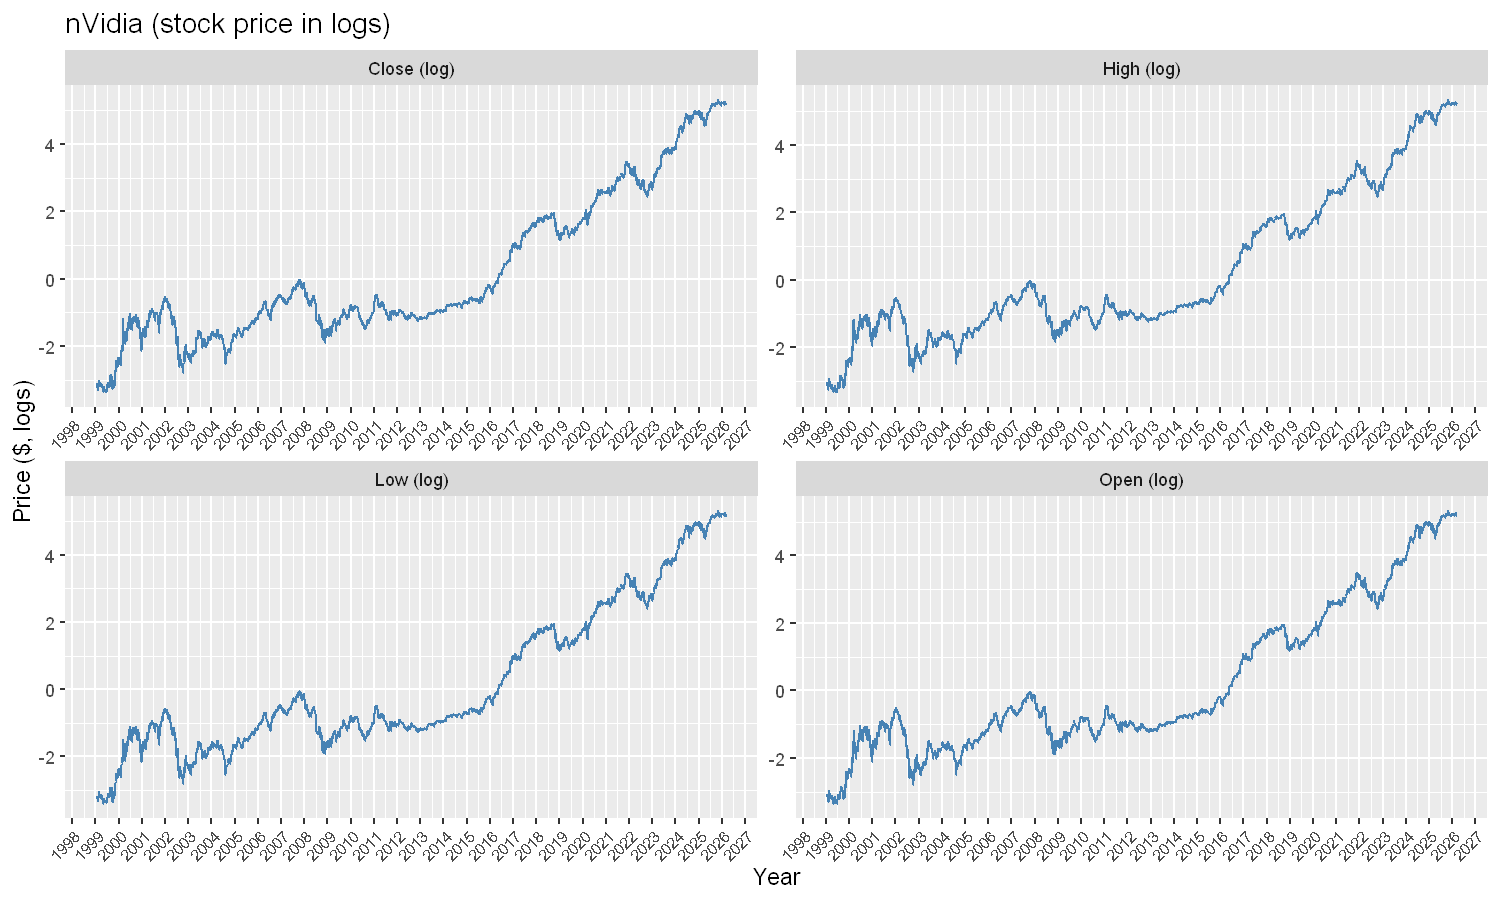

In [321]:
# Price in logs
log_cols <- c("close", "high", "low", "open")

cat("\nSeries in logs:\n")
nvidia_df |>
    mutate(
        across(
            .cols = all_of(log_cols),
            .fns = ~ log(.x),
            .names = "{.col}_log"
        )
    ) |>
    select(date, all_of(paste0(log_cols, "_log"))) |>
    pivot_longer(
        cols = -date,
        names_to = "var",
        values_to = "val"
    ) |>
    mutate(
        var = str_to_sentence(str_replace_all(var, "(_)([a-z]+)$", " (\\2)"))
    ) |>
    ggplot(aes(x = date, y = val)) +
    geom_line(colour = "steelblue") +
    facet_wrap(~var, scales = "free", ncol = 2) +
    scale_x_date(
        date_breaks = "1 year",
        date_labels = "%Y"
    ) +
    labs(title = "nVidia (stock price in logs)", x = "Year", y = "Price ($, logs)") +
    theme(axis.text.x = element_text(size = 7, angle = 45, hjust = 1))

All four series look similar as we would expect. The shape of the data indicates a random walk with a drift.


Log returns:


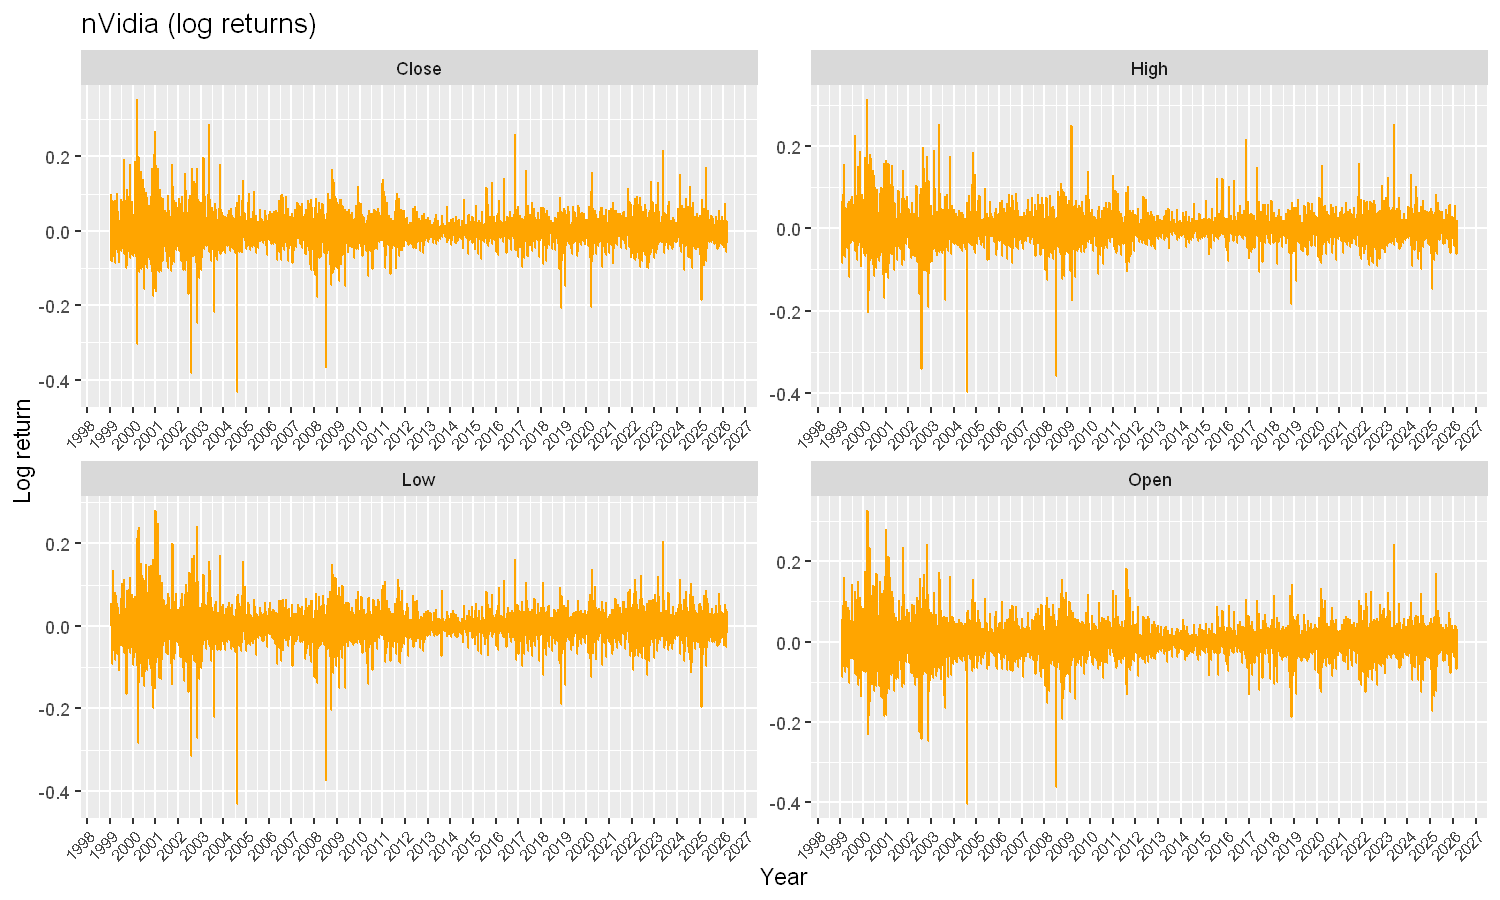

In [322]:
# Differenced series in logs
returns_df <- nvidia_df |>
    select(date, all_of(log_cols)) |>
    mutate(
        across(
            .cols = where(is.numeric),
            .fns = ~ log(.x) - lag(log(.x)),
            .names = "{.col}_ret"
        )  
    ) |>
    select(date, ends_with("ret")) |>
    pivot_longer(
        cols = -date,
        names_pattern = "([a-z]+)_ret",
        names_to = "var",
        values_to = "val"
    ) |>
    drop_na(val)

cat("\nLog returns:\n")
returns_df |>
    mutate(
        var = str_to_sentence(str_replace_all(var, "(_)([a-z]+)$", " (\\2)"))
    ) |>
    ggplot(aes(x = date, y = val)) +
    geom_line(colour = "orange") +
    facet_wrap(~var, scales = "free", ncol = 2) +
    scale_x_date(
        date_breaks = "1 year",
        date_labels = "%Y"
    ) +
    labs(title = "nVidia (log returns)", x = "Year", y = "Log return") +
    theme(axis.text.x = element_text(size = 7, angle = 45, hjust = 1))

Log returns appear to be stationary. Interestingly, returns seem to have been more volatile in nVidia's early days. This perhaps makes sense when we consider that a small movement would have caused large deviations relative to the low early stock price.


Absolute and squared returns:


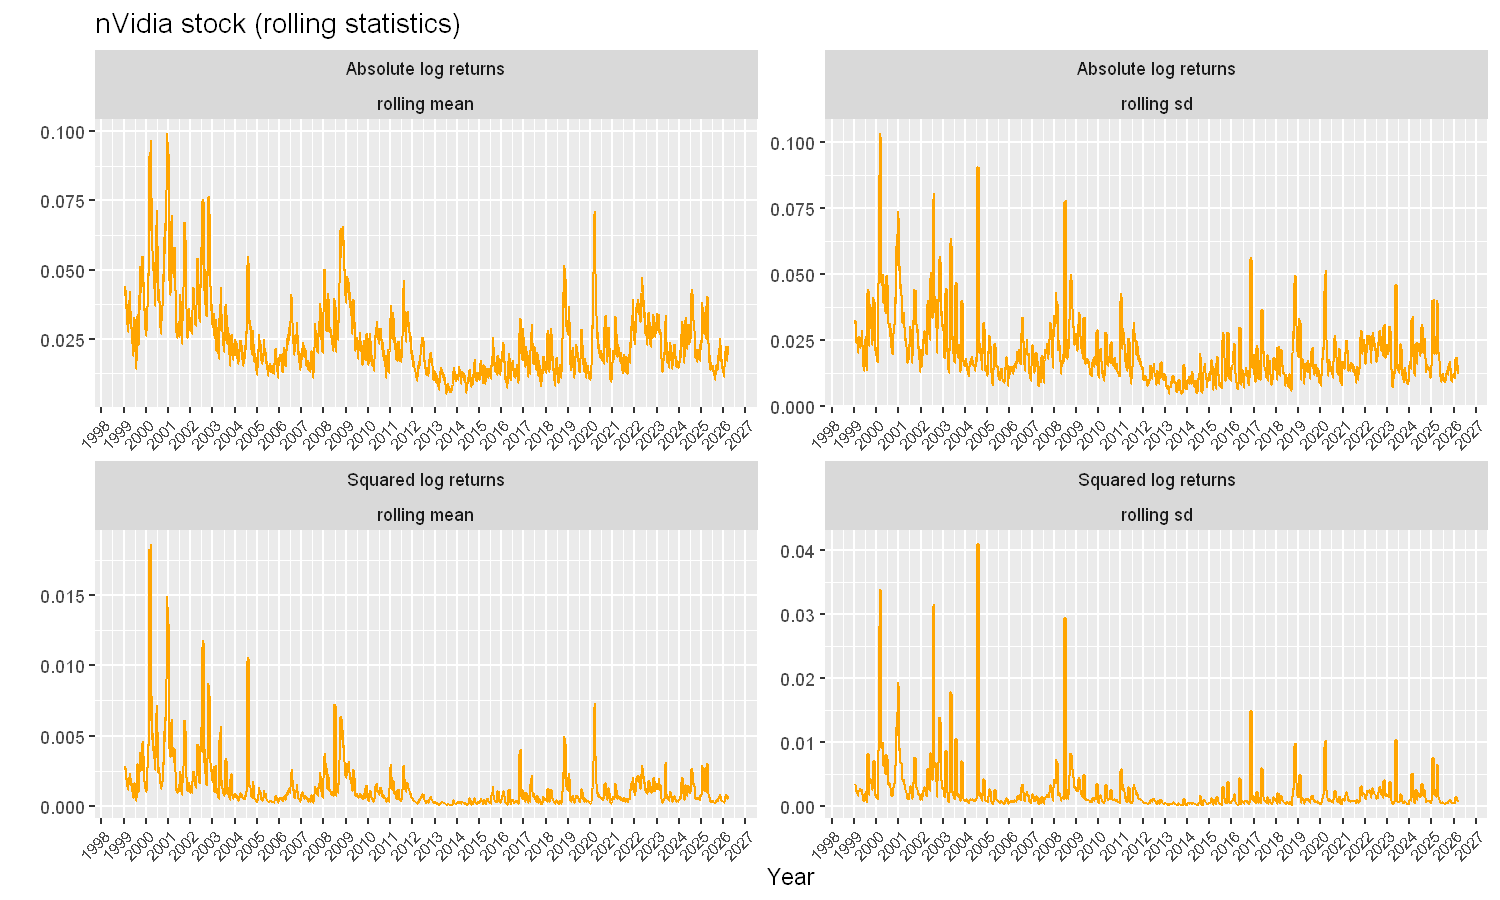

In [342]:
# Rolling stats
rollstats_df <- returns_df |>
    filter(var == "close") |>
    rename(r = val) |>
    mutate(
        r = abs(r),
        rsq = r^2,
        r_rollmean = rollapply(r, 21, mean, partial = TRUE),
        rsq_rollmean = rollapply(rsq, 21, mean, partial = TRUE),
        r_rollsd = rollapply(r, 21, sd, partial = TRUE),
        rsq_rollsd = rollapply(rsq, 21, sd, partial = TRUE)
    ) |>
    select(-c(var, r, rsq)) |>
    pivot_longer(
        cols = -date,
        names_to = "var",
        values_to = "val"
    ) |>
    mutate(
        type = case_when(
            str_detect(var, "rollmean$") ~ "rolling mean",
            str_detect(var, "rollsd$") ~ "rolling sd",
            .default = NA_character_
        ),
        var = case_when(
            str_detect(var, "^r_") ~ "Absolute log returns",
            str_detect(var, "^rsq_") ~ "Squared log returns",
            .default = var
        )
    )

cat("\nAbsolute and squared returns:\n")
rollstats_df |>
    ggplot(aes(x = date, y = val)) +
    geom_line(colour = "orange") +
    facet_wrap(var ~ type, scales = "free", ncol = 2) +
    scale_x_date(
        date_breaks = "1 year",
        date_labels = "%Y"
    ) +
    labs(title = "nVidia stock (rolling statistics)", x = "Year", y = "") +
    theme(axis.text.x = element_text(size = 7, angle = 45, hjust = 1))
    

nVidia's eraly years show higher volatility. Following the GFC (2009), there seems to be a somewhat quiet period until 2017. Our dataset alone may not allow us to investigate the context without more or less informed guesswork.


Log returns:


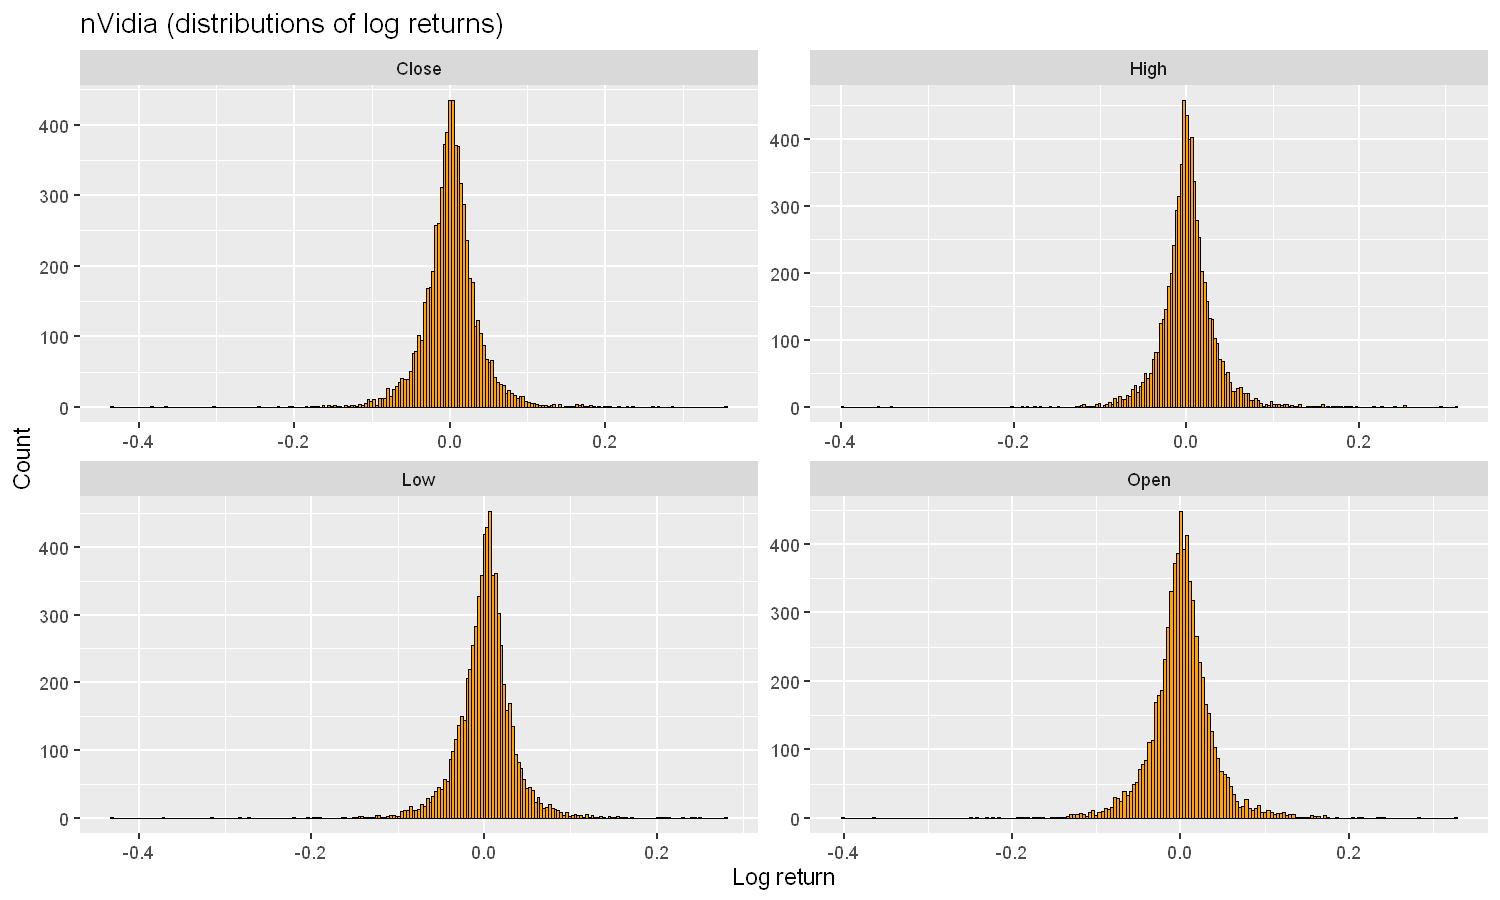

In [152]:
cat("\nLog returns:\n")
returns_df |>
    mutate(var = str_to_sentence(var)) |>
    ggplot(aes(x = val)) +
    geom_histogram(
        # Freedman-Diaconis bin width
        binwidth = \(x) 2 * IQR(x) * length(x)^(-1 / 3), 
        colour = "black", linewidth = 0.01, fill = "orange"
    ) +
    facet_wrap(~var, scale = "free") +
    labs(
        title = "nVidia (distributions of log returns)",
        x = "Log return",
        y = "Count"
    )

The histograms indicate the differenced data have somewhat symmetrical distributions and an apparently reasonably low variance, but outliers show in all four graphs.


Log returns:


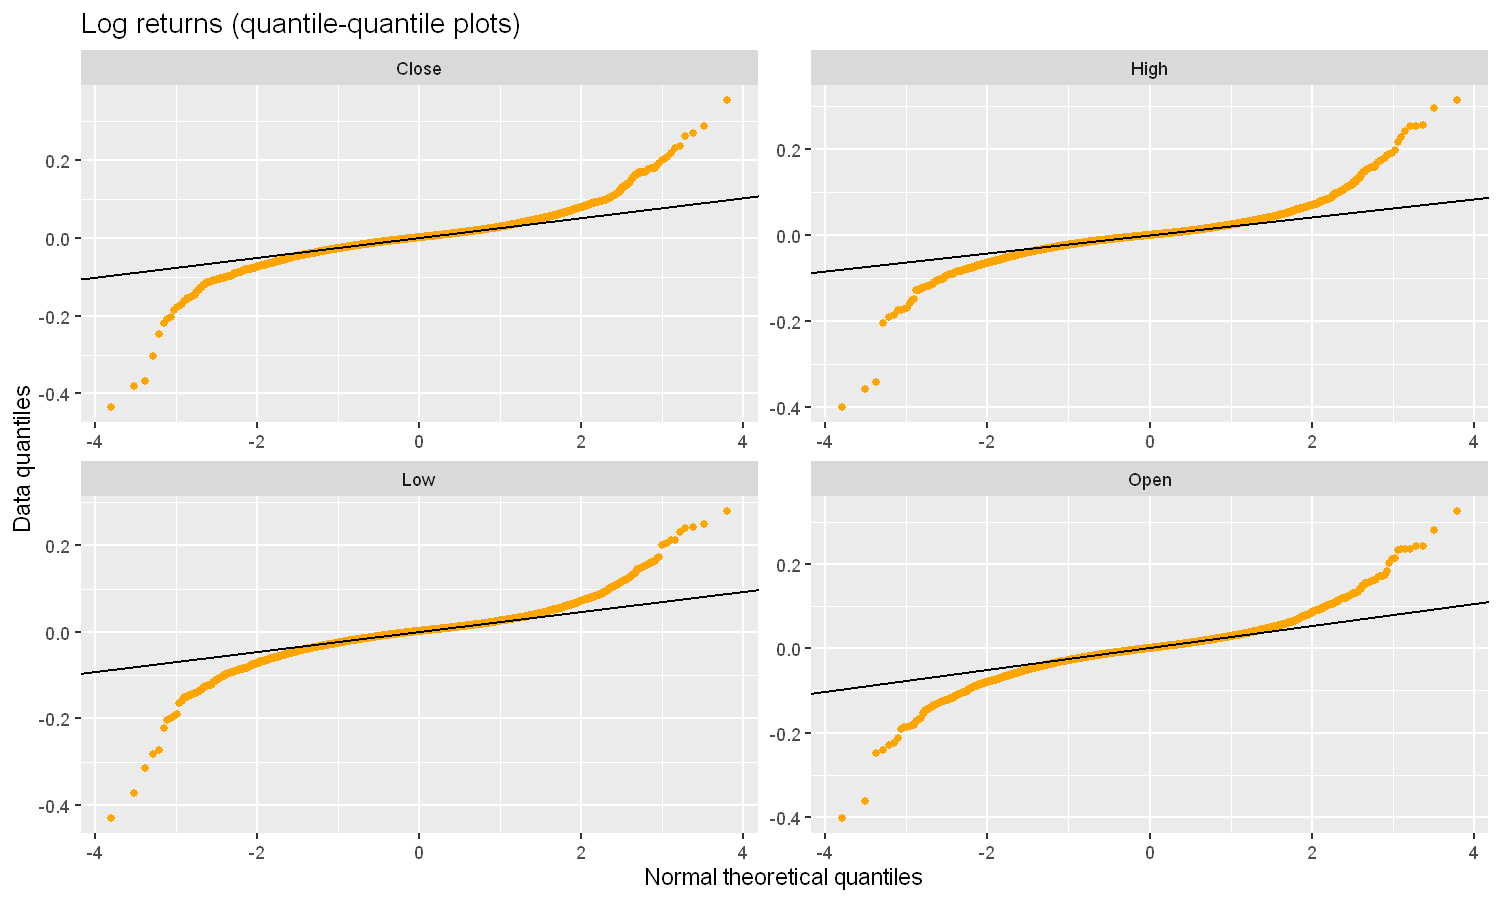

In [112]:
# QQ plot
cat("\nLog returns:\n")
returns_df |>
    mutate(var = str_to_sentence(var)) |>
    ggplot(aes(sample = val)) +
    stat_qq(colour = "orange") + 
    stat_qq_line() +
    facet_wrap(~var, scales = "free") + 
    labs(
        title = "Log returns (quantile-quantile plots)",
        x = "Normal theoretical quantiles",
        y = "Data quantiles"
    )

The tilt of the qq line southwards of 45 degrees confirms the low variance. The tails of the data appear symmetrical, but their curving away counter-clockwise confirms the fat tails.

In [130]:
# Normality test
cat("\nJarque-Bera test:\n")
returns_df |>
    group_by(var) |>
    summarise(
        statistic = tseries::jarque.bera.test(val)$statistic,
        pval = tseries::jarque.bera.test(val)$p.value,
        .groups = "drop"
    ) |>
    mutate(
        `p<0.05` = pval < 0.05
    )


Jarque-Bera test:


var,statistic,pval,p<0.05
<chr>,<dbl>,<dbl>,<lgl>
close,42359.79,0,TRUE
high,63937.08,0,TRUE
low,47271.57,0,TRUE
open,20763.80,0,TRUE


The Jarque-Bera test indicates non-normality, but this would likely be the case regardless owing to the large sample size.


Absolute and squared returns:


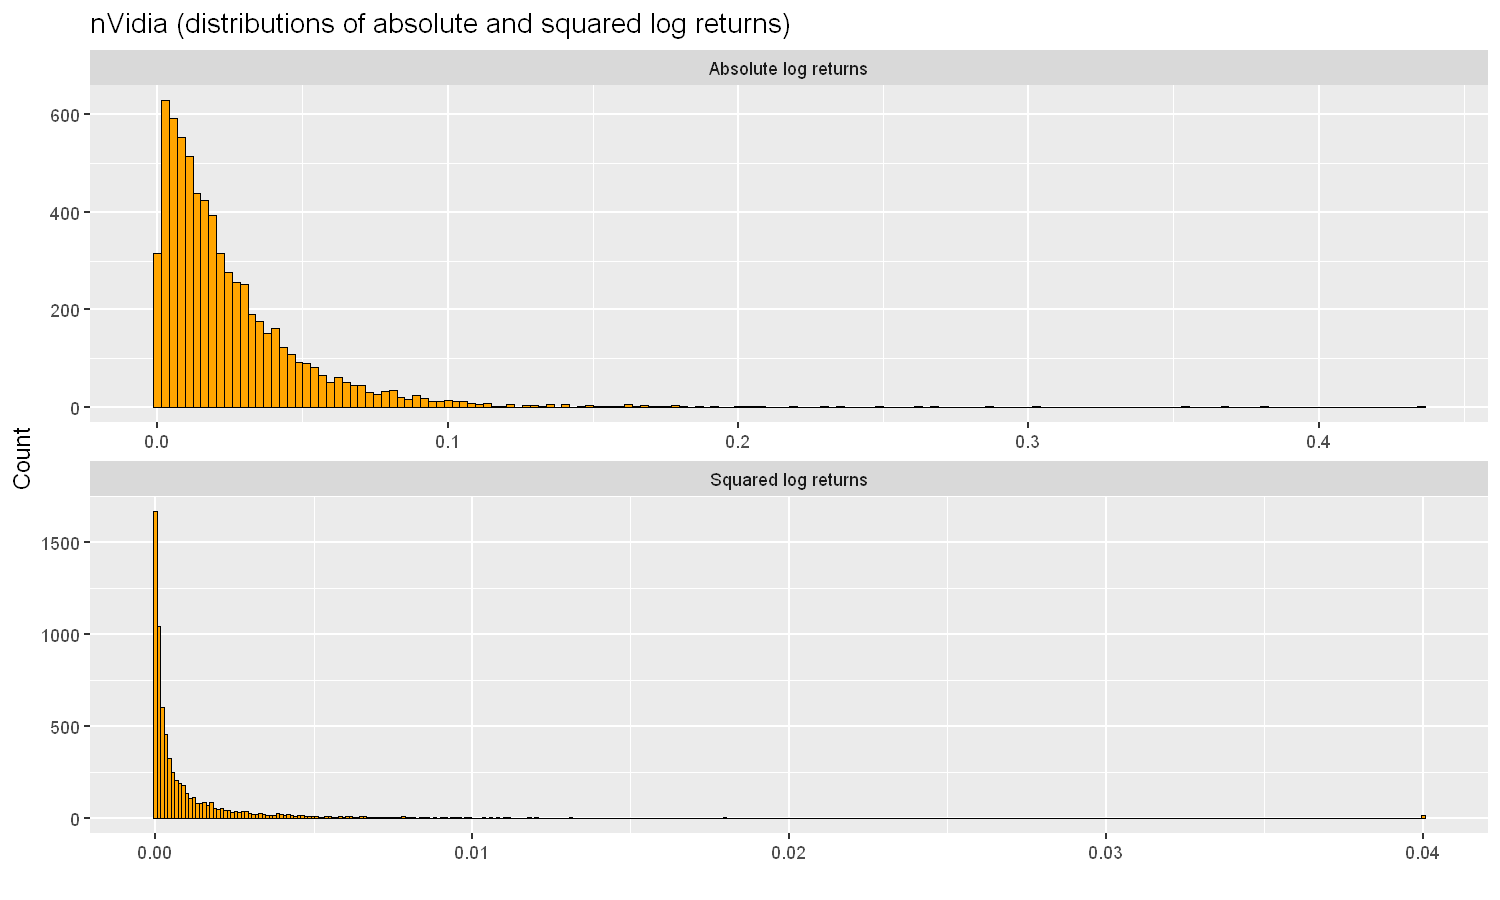

In [341]:
squared_returns_df <- returns_df |>
    filter(var == "close") |>
    mutate(
        r = abs(val),
        rsq = r^2
    ) |>
    select(-c("var", "val")) |>
    pivot_longer(
        cols = c("r", "rsq"),
        names_to = "var",
        values_to = "val"
    ) |>
    mutate(
        var = case_when(
            var == "r" ~ "Absolute log returns",
            var == "rsq" ~ "Squared log returns",
            .default = var
        )
    )
    
cat("\nAbsolute and squared returns:\n")
squared_returns_df |>
    mutate(
        val = if_else(var == "Squared log returns", pmin(val, 0.04), val)
    ) |>
    ggplot(aes(x = val)) +
    geom_histogram(
        # Freedman-Diaconis bin width
        binwidth = \(x) 2 * IQR(x) * length(x)^(-1 / 3), 
        colour = "black", linewidth = 0.01, fill = "orange"
    ) +
    facet_wrap(~var, scales = "free", ncol = 1) + 
    labs(
        title = "nVidia (distributions of absolute and squared log returns)",
        x = "",
        y = "Count"
    )

#### Seasonality


Daily log returns:


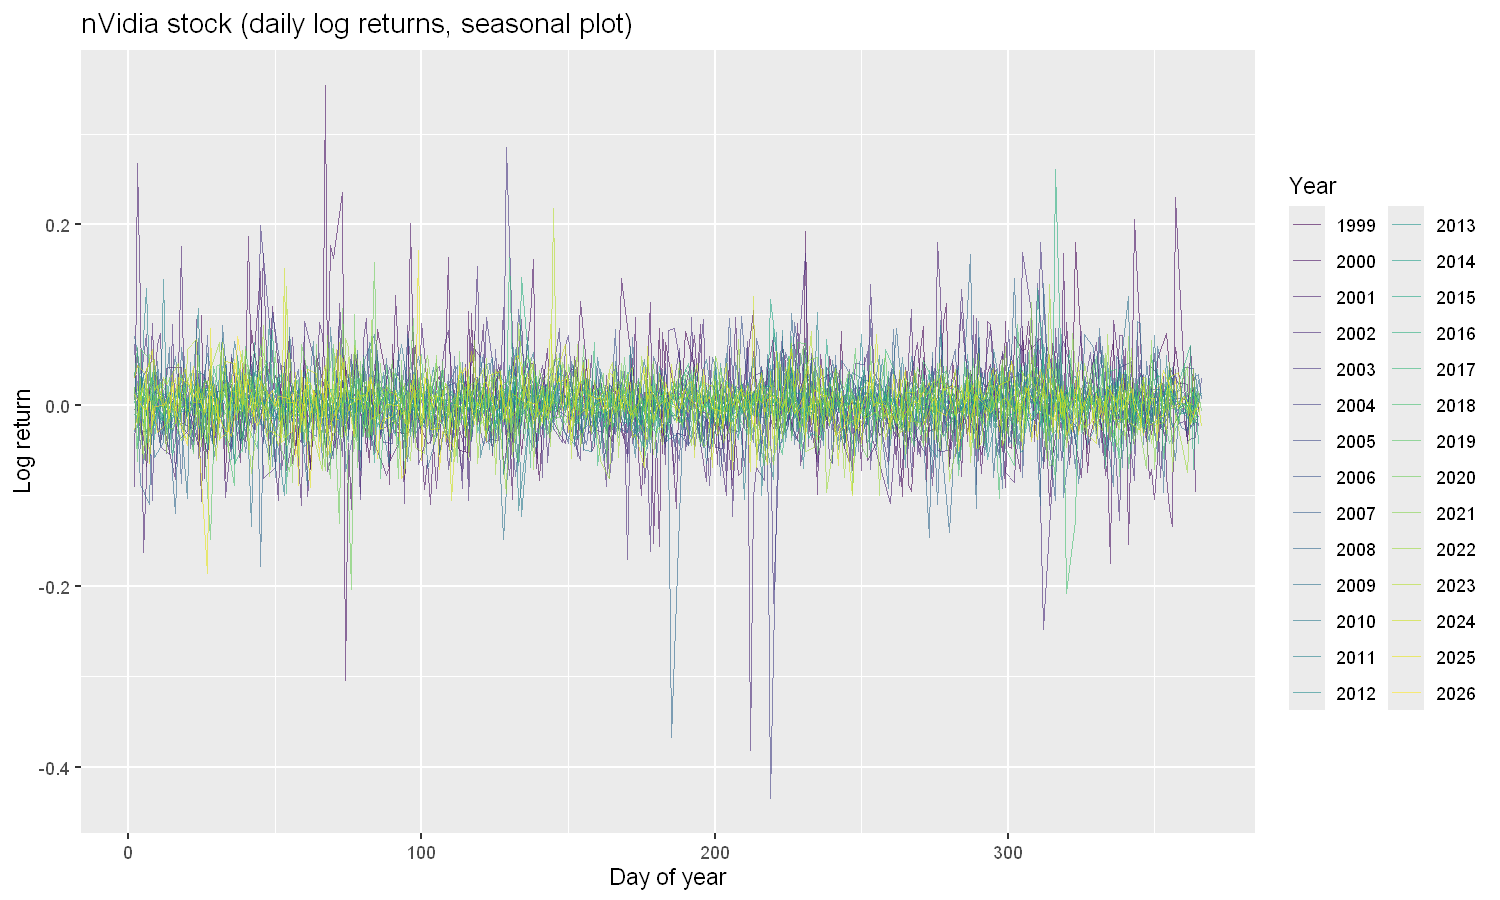

In [197]:
# Seasonal plot (daily)
# Emulate faceted tsibble() |> gg_season()
daily_returns <- returns_df |>
    filter(var == "close") |>
    mutate(
        year = year(date),
        month = month(date, label = TRUE),
        yday = yday(date),
        mday = mday(date)
    )

cat("\nDaily log returns:\n")
daily_returns |>
    ggplot(aes(x = yday, y = val, colour = factor(year), group = factor(year))) +
    geom_line(linewidth = 0.3, alpha = 0.6) +
    scale_colour_viridis_d(name = "Year") +
    labs(
        title = "nVidia stock (daily log returns, seasonal plot)",
        x = "Day of year",
        y = "Log return"
    )


Daily log returns:


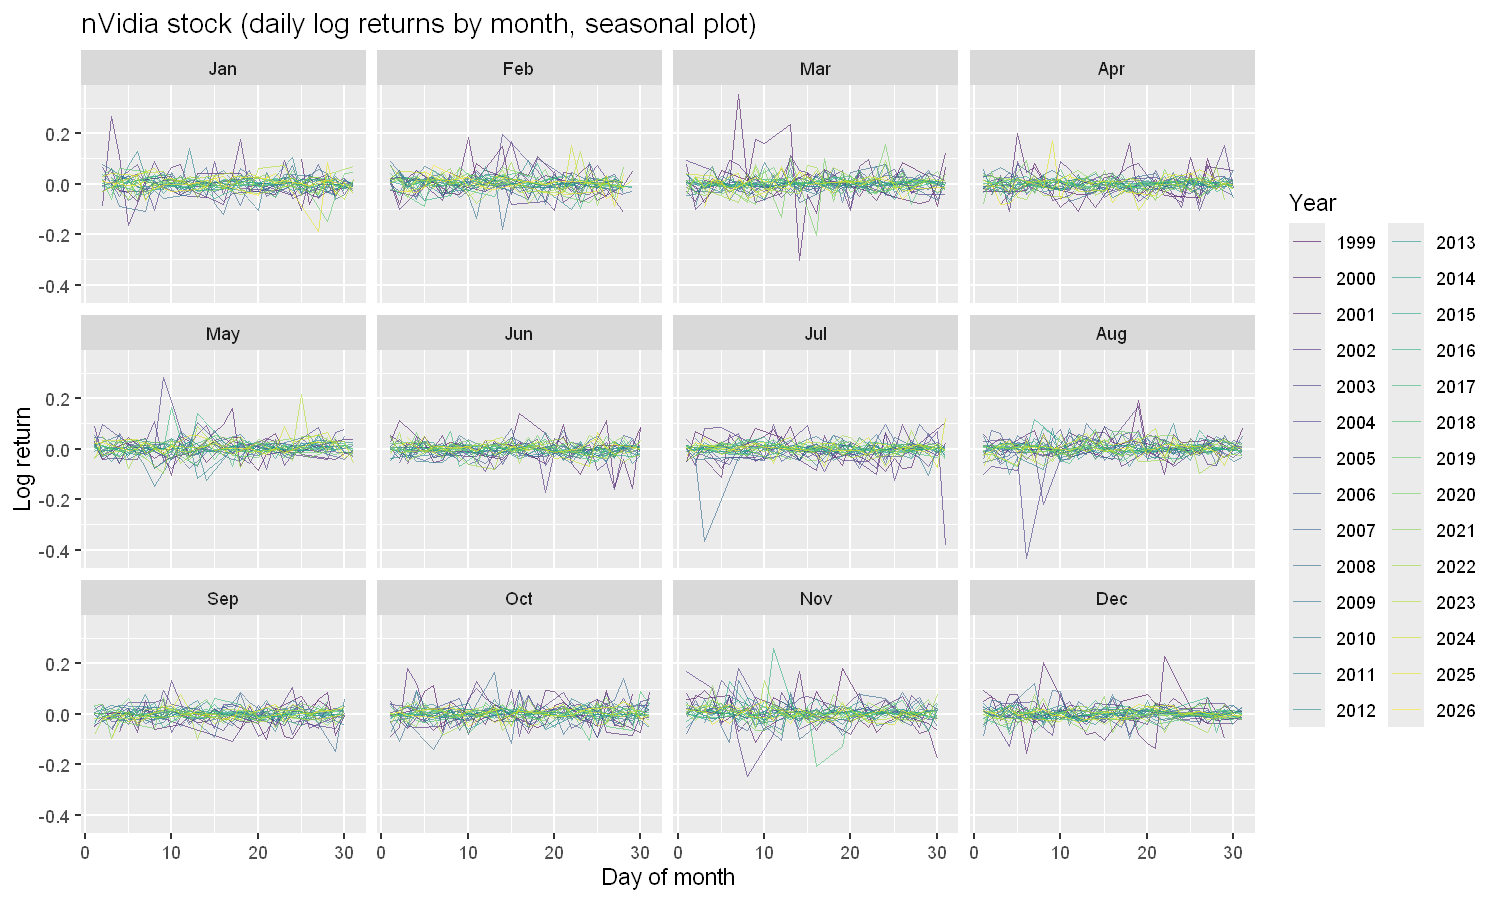

In [198]:
# Seasonal plot (daily by month)
cat("\nDaily log returns:\n")
daily_returns |>
    ggplot(aes(x = mday, y = val, colour = factor(year), group = factor(year))) +
    geom_line(linewidth = 0.3, alpha = 0.6) +
    facet_wrap(~month, ncol = 4) +
    scale_colour_viridis_d(name = "Year") +
    labs(
        title = "nVidia stock (daily log returns by month, seasonal plot)",
        x = "Day of month",
        y = "Log return"
    )

There is no more of a seasonal pattern in daily returns plotted by month.

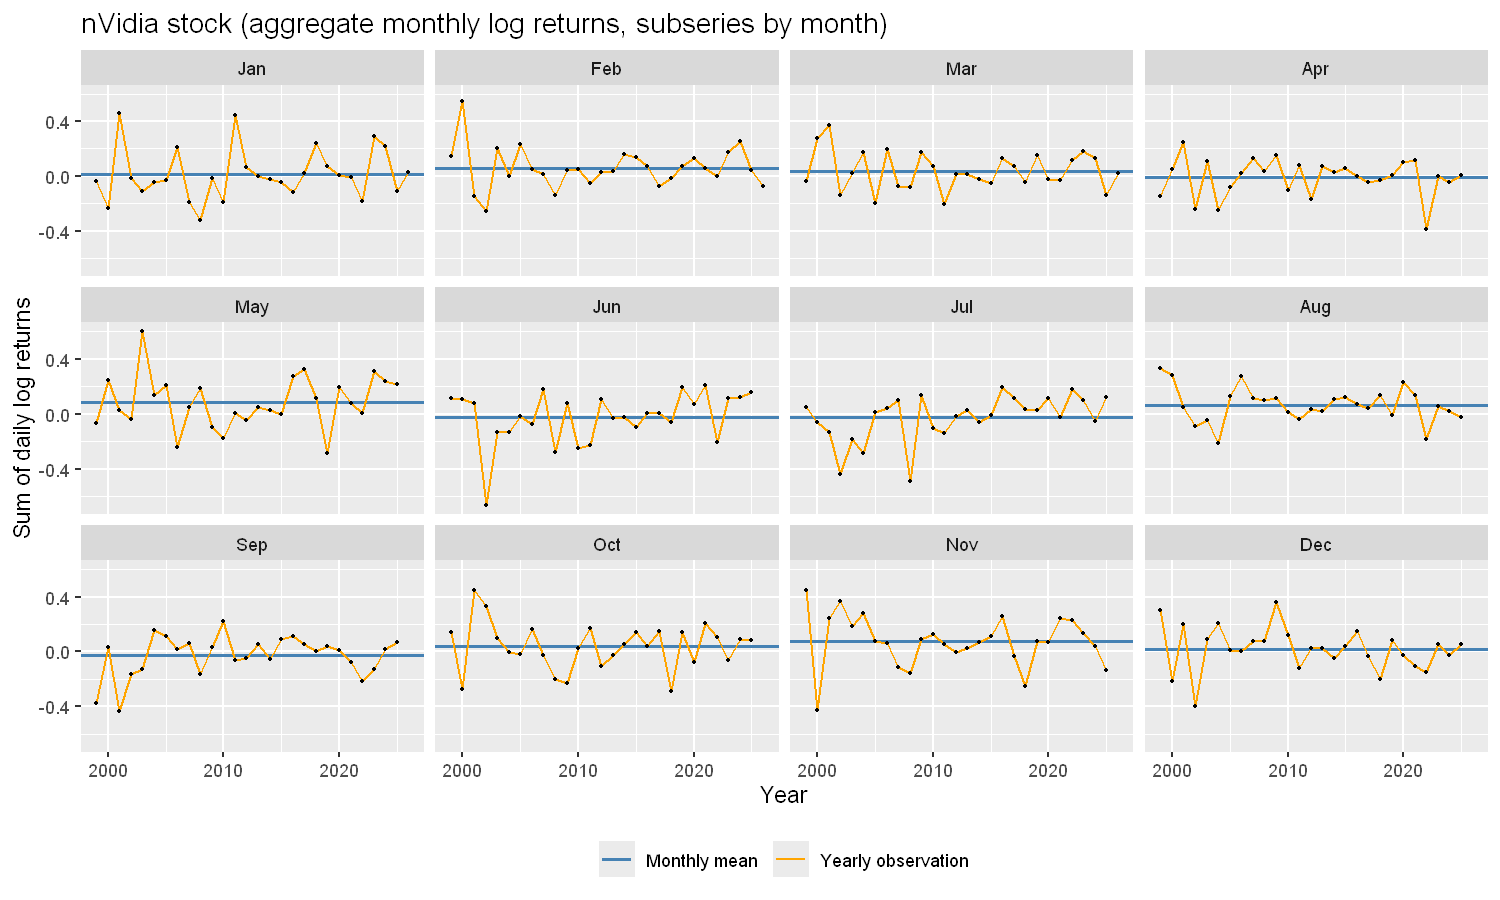

In [199]:
# Seasonal plot (monthly)
# Emulate tsibble() |> ggtime::gg_subseries()
monthly_returns <- nvidia_df |>
    log_returns() |>
    group_by(
        period = floor_date(date, "month")
    ) |>
    summarise(
        close_lr = sum(close_lr, na.rm = TRUE),
        .groups = "drop"
    ) |>
    mutate(
        year = year(period),
        month = month(period, label = TRUE)
    )
    
month_agg <- monthly_returns |>
    group_by(month) |>
    summarise(month_mean = mean(close_lr)) |>
    ungroup()

monthly_returns |>
    ggplot(aes(x = year, y = close_lr)) +
    geom_hline(
        data = month_agg,
        aes(yintercept = month_mean, colour = "Monthly mean"), 
        linewidth = 0.7
    ) +
    geom_line(aes(colour = "Yearly observation"), linewidth = 0.6) +
    geom_point(size = 0.5) +
    facet_wrap(~month, ncol = 4) +
    labs(
        title = "nVidia stock (aggregate monthly log returns, subseries by month)", 
        x = "Year",
        y = "Sum of daily log returns"
    ) +
    scale_colour_manual(
        name = NULL,
        values = c("Monthly mean" = "steelblue", "Yearly observation" = "orange")
    ) +
    theme(
        legend.position = "bottom"
    )

As is typical of a stock series, there is no seasonal pattern. Although there appear to be exceptions, such as May, August and November, returns typically average zero as per efficient market hypothesis.


Daily log returns:


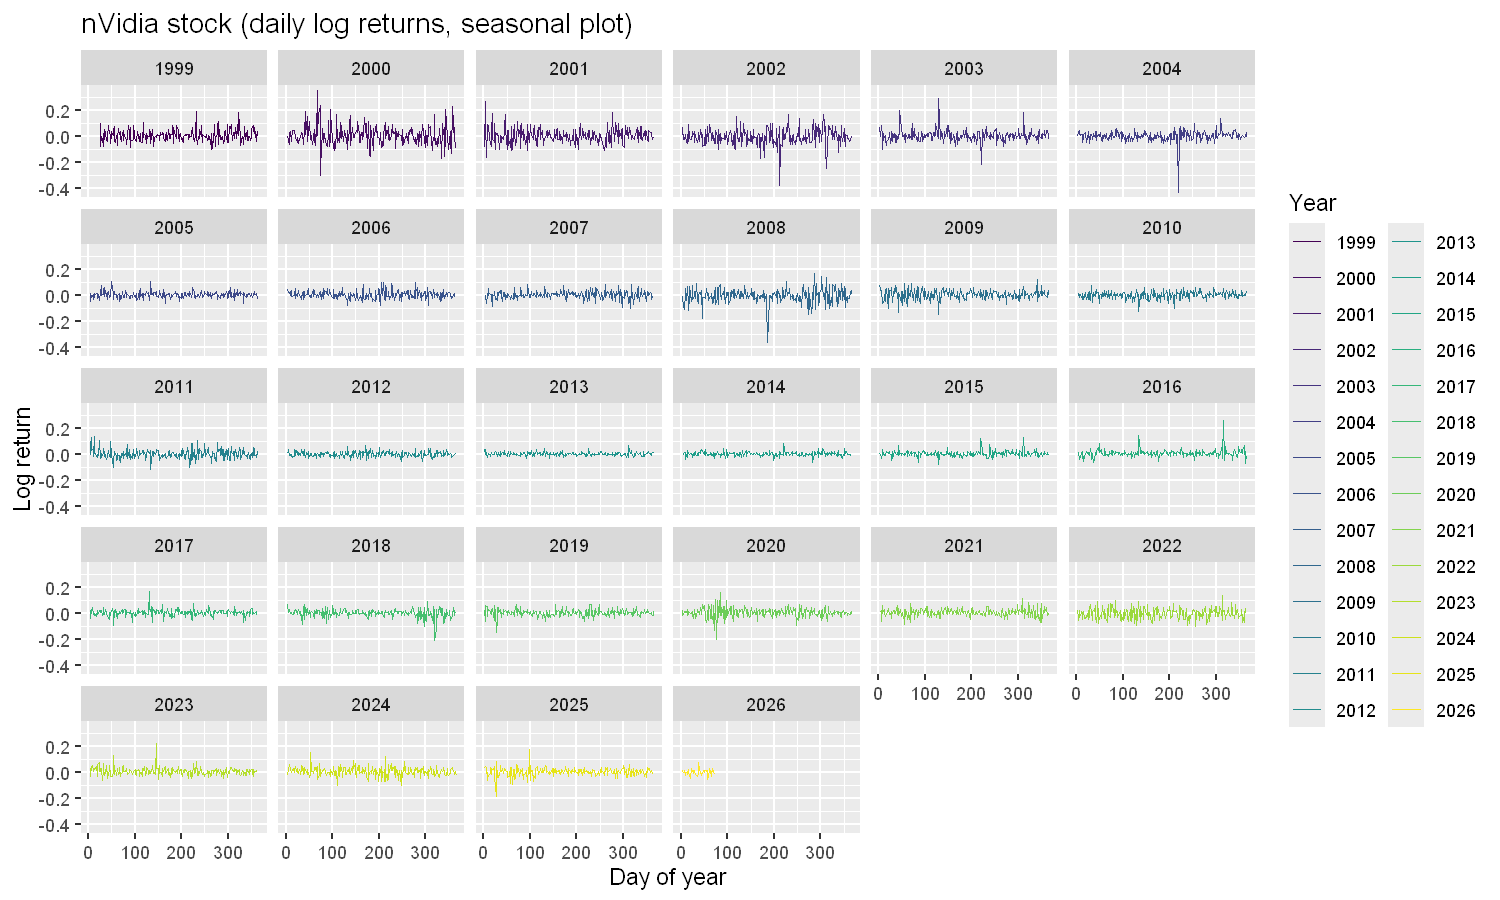

In [309]:
# Seasonal plot (daily by year)
# Emulate tsibble() |> ggtime::gg_seasonal()

cat("\nDaily log returns:\n")
returns_df |>
    filter(var == "close") |>
    mutate(
        year = year(date), 
        yday = yday(date)
    ) |>
    ggplot(aes(x = yday, y = val, colour = factor(year))) +
    geom_line(linewidth = 0.4) +
    facet_wrap(~year) +
    scale_colour_viridis_d(name = "Year") +
    labs(
        title = "nVidia stock (daily log returns, seasonal plot)", 
        x = "Day of year",
        y = "Log return", 
        colour = "Year"
    )

As expected, there does not seem to be a discernible seasonal pattern in daily returns. We can see curious spikes, however. The volatility of returns seems to be diminishing over time with noticeable exceptions in GFC (2008), 2011 and 2022. Late 2018 and the onset of the pandemic (2020), for some examples.

#### Temporal correlations


Daily log returns:


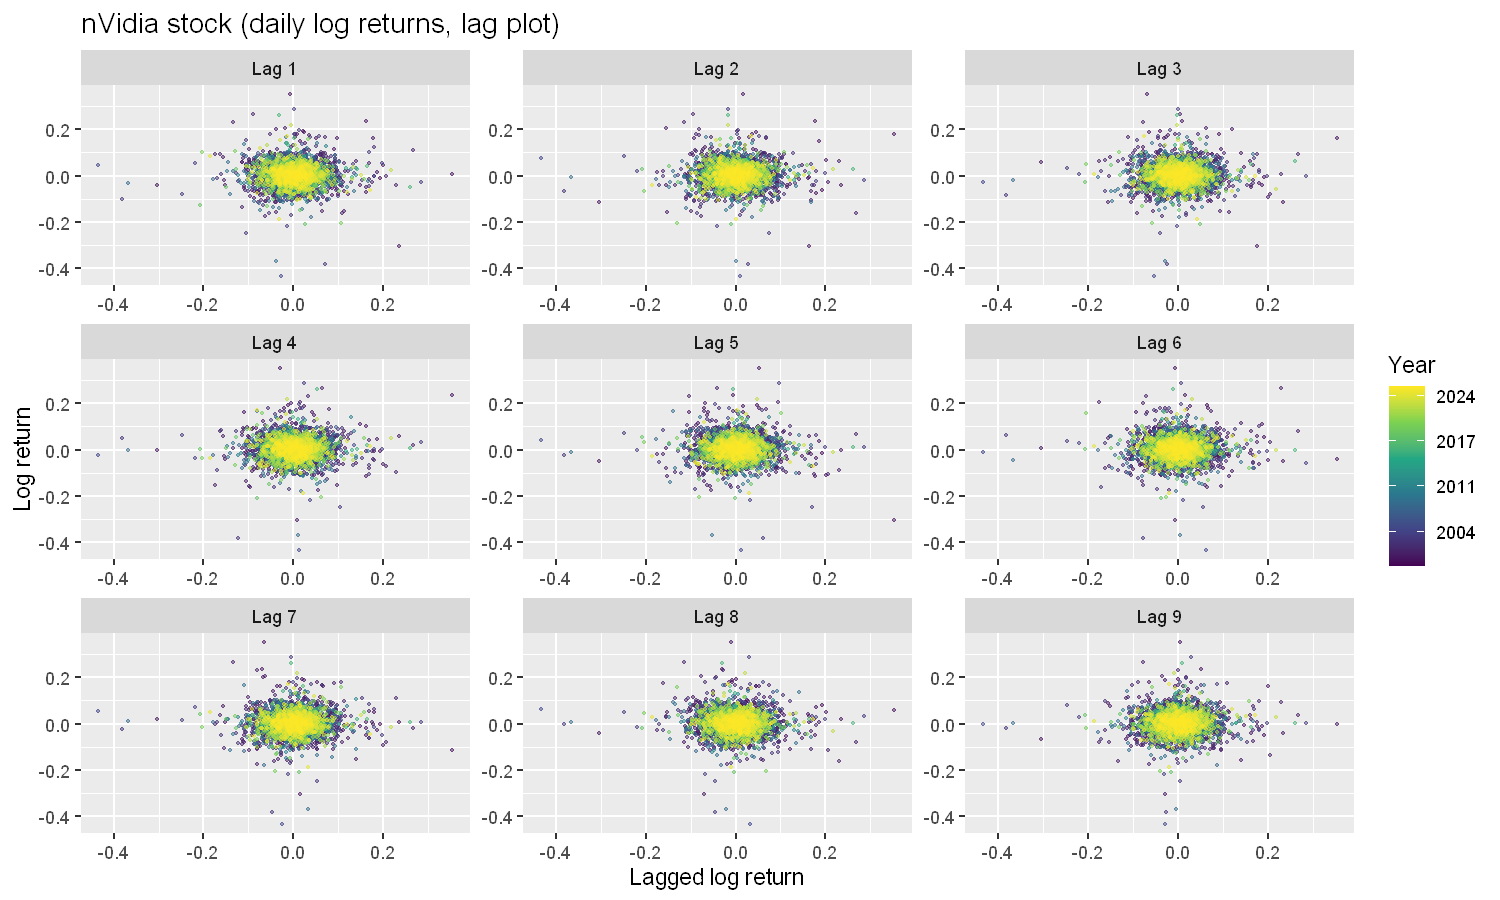

In [226]:
# Lag plots (returns)
# Emulate tsibble() |> ggtime::gg_lag()
daily_returns <- nvidia_df |>
    log_returns() |>
    select(date, close_lr)

cat("\nDaily log returns:\n")
p <- 9 # Lags
map_dfr(
        seq(p), 
        \(k) {
        daily_returns |> mutate(lag_val = lag(close_lr, k), lag_k = k)
        }
    ) |>
    drop_na(lag_val) |>
    ggplot(aes(x = lag_val, y = close_lr, colour = as.numeric(date))) +
    geom_point(size = 0.5, alpha = 0.5) +
    facet_wrap(~paste("Lag", lag_k), scales = "free") +
    scale_colour_viridis_c(
        name   = "Year",
        labels = \(x) format(as_date(x), "%Y")
    ) +
    labs(
        title = "nVidia stock (daily log returns, lag plot)",
        x = "Lagged log return",
        y = "Log return"
    )

There is no discernible correlation in daily log returns.


Squared daily log returns:


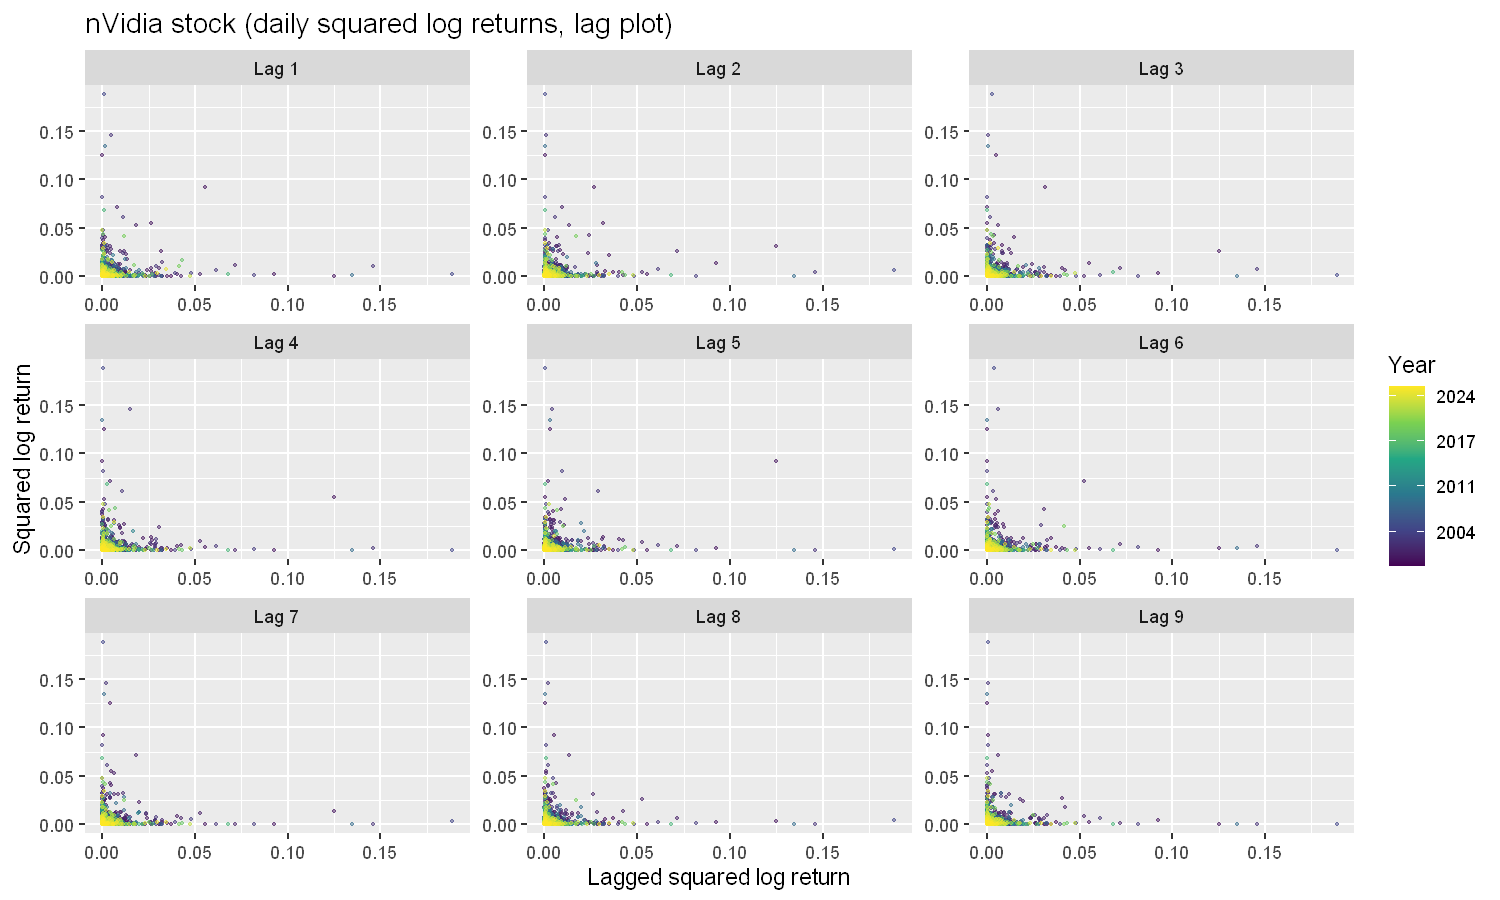

In [225]:
# Lag plots (squared returns)
squared_daily_returns <- daily_returns |>
    mutate(close_lrsq = close_lr^2)

cat("\nSquared daily log returns:\n")
map_dfr(
        seq(p), 
        \(k) {
        squared_daily_returns |> mutate(lag_val = lag(close_lrsq, k), lag_k = k)
        }
    ) |>
    drop_na(lag_val) |>
    ggplot(aes(x = lag_val, y = close_lrsq, colour = as.numeric(date))) +
    geom_point(size = 0.5, alpha = 0.5) +
    facet_wrap(~paste("Lag", lag_k), scales = "free") +
    scale_colour_viridis_c(
        name   = "Year",
        labels = \(x) format(as_date(x), "%Y")
    ) +
    labs(
        title = "nVidia stock (daily squared log returns, lag plot)",
        x = "Lagged squared log return",
        y = "Squared log return"
    )

There is no discernible correlation in squared log returns either.


ACF and PACF for daily log returns:


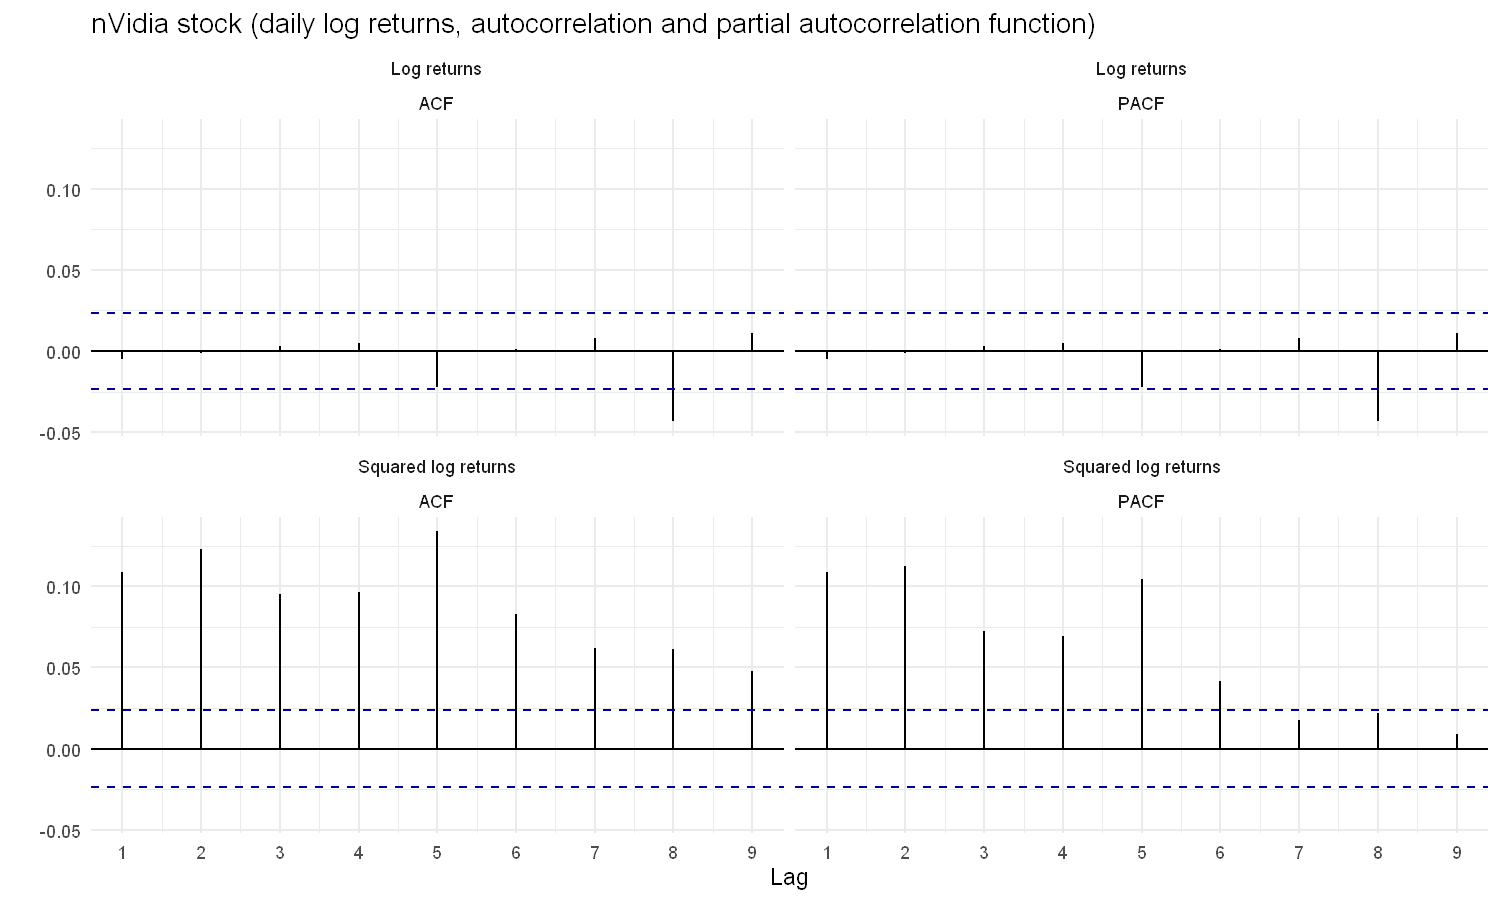

In [310]:
# ACF/PACF
# Emulate tsibble() |> feasts::ACF() |> autoplot()
ci_line <- qnorm((1 + 0.95) / 2) / sqrt(nrow(daily_returns))

acf_df <- tibble(
        lag = seq(p)
    )
    
for (c in colnames(select(squared_daily_returns, - date))) {
    col <- squared_daily_returns[[c]]

    if (str_detect(c, "sq")) { n <- "squared_log_returns"} else { n <- "log_returns" }

    acf_df[[paste0(n, "_acf")]] <- as.numeric(acf(col, plot = FALSE, lag.max = p)$acf[-1])
    acf_df[[paste0(n, "_pacf")]] <- as.numeric(pacf(col, plot = FALSE, lag.max = p)$acf)
}

acf_df <- acf_df |>
    pivot_longer(
        cols = -lag,
        names_pattern = "(.+)_(acf|pacf)$",
        names_to = c("var", "type")
    ) |>
    mutate(
        var = str_to_sentence(str_replace_all(var, "_", " ")), 
        type = str_to_upper(type)
    )

cat("\nACF and PACF for daily log returns:\n")
acf_df |>
    ggplot(aes(x = lag, y = value)) +
    geom_hline(aes(yintercept = 0)) +
    geom_segment(mapping = aes(xend = lag, yend = 0)) +
    geom_hline(yintercept = ci_line, linetype = 2, color = 'darkblue') +
    geom_hline(yintercept = -ci_line, linetype = 2, color = 'darkblue') + 
    facet_wrap(var ~ type) +
    #scale_x_continuous(breaks = 1:9) +
    scale_x_continuous(breaks = scales::breaks_width(1)) +
    labs(
        title = "nVidia stock (daily log returns, autocorrelation and partial autocorrelation function)", 
        x = "Lag", 
        y = ""
    ) +
    theme_minimal()

We can see that log returns are a white noise process. Squared log returns appear to have retained temporal correlations. This may be an ARCH or GARCH process.

In [ ]:
# ADF/KPSS
for (c in colnames(select(squared_daily_returns, -date))) {
    col <- squared_daily_returns[[c]]

    kpss <- urca::ur.kpss(col, type = "mu", lags = "short")
    adf <- urca::ur.df(col, type = "none", selectlags = "AIC")

    df <- tibble(
        
    )
}

kpss |> str()

Formal class 'ur.kpss' [package "urca"] with 7 slots
  ..@ y        : num [1:6826] 9.93e-03 6.52e-03 9.70e-06 9.92e-06 2.32e-03 ...
  ..@ type     : chr "mu"
  ..@ lag      : int 11
  ..@ cval     : num [1, 1:4] 0.347 0.463 0.574 0.739
  .. ..- attr(*, "dimnames")=List of 2
  .. .. ..$ : chr "critical values"
  .. .. ..$ : chr [1:4] "10pct" "5pct" "2.5pct" "1pct"
  ..@ teststat : num 6.29
  ..@ res      : num [1:6826] 0.008533 0.00513 -0.001384 -0.001384 0.000926 ...
  ..@ test.name: chr "KPSS"


In [272]:
# Plot the price at close
#cat("\nPrice at close and log price at close:\n")
#par(mfrow = c(2, 1))

#plot(
#    x = nvidia_df$date, 
#    y = nvidia_df$close, 
#    type = "l",
#    main = "nVidia stock price at close",
#    xlab = "Date",
#    ylab = "Price"
#)

#plot(
#    x = nvidia_df$date, 
#    y = log(nvidia_df$close), 
#    type = "l",
#    main = "nVidia stock price at close in logs",
#    xlab = "Date",
#    ylab = "Price (log)"
#)

In [273]:
#cat("\nFirst differences and returns:\n")
#par(mfrow = c(2, 1))

#plot(
#    x = nvidia_df$date, 
#    y = nvidia_df$close - lag(nvidia_df$close), 
#    type = "l",
#    main = "nVidia stock price at close in differences",
#    xlab = "Date",
#    ylab = "Price change"
#)

#plot(
#    x = nvidia_df$date, 
#    y = (nvidia_df$close - lag(nvidia_df$close)) / lag(nvidia_df$close), 
#    type = "l",
#    main = "Returns on nVidia stocks",
#    xlab = "Date",
#    ylab = "Returns"
#)

#par(mfrow = c(1, 1))